In [1]:
import numpy as np
import pandas as pd
import math
import os, sys
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer
from catboost import CatBoostRegressor

sys.path.insert(0, '../')
# sys.path.insert(0, '.../')
from utils.utilities import *

In [2]:
class Dataset:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.x)
    
    def __getitem__(self, i):
        if isinstance(i, (pd.Series, np.ndarray)) and i.dtype == bool:
            return Dataset(self.x[i], self.y[i])
        return self.x[i], self.y[i]
    
    def copy(self, deep=True):
        if deep:
            return Dataset(self.x.copy(), self.y.copy())
        else:
            return Dataset(self.x, self.y)
    
def to_dataset(df, target):
    mask = ~df.columns.isin([target])
    x = df.loc[:, mask]
    y = df[target]

    return Dataset(x, y)

# Load Data

In [ ]:
BASE_DIR = Path.cwd().parent.parent

df_dt = pd.read_csv(BASE_DIR / 'data/flight_data_2024_data_dictionary.csv')
df = pd.read_csv(BASE_DIR / 'data/flight_data_2425_fe.csv')

# Convert DType


In [8]:
dtypes = dict(zip(df_dt['column'], df_dt['dtype']))
df1 = df1.drop(columns=['fl_date'])
df2 = df2.drop(columns=['fl_date'])

In [9]:
def dtype_converter(df: pd.DataFrame, dtype_dict: dict):
    for col in df.columns:
        if col == 'fl_date':
            continue
        if df[col].isna().sum() != 0 and (dtype_dict[col] == 'int64' or dtype_dict[col] == 'int32'):
            df[col] = df[col].astype('Int64')
        else:
            df[col] = df[col].astype(dtype_dict[col])

    return df

In [10]:
df1 = dtype_converter(df1, dtypes)
df2 = dtype_converter(df2, dtypes)
df = pd.concat([df1, df2], axis=0)

# Basic Filter


In [11]:
thres = 0.2
n = len(df)
na_cols = []
for idx, val in df.isna().sum().items():
    if val > (thres * n):
        na_cols.append(idx)

df_filtered = df.drop(columns=na_cols, errors='ignore')

In [12]:
df_filtered = df_filtered.dropna(subset=['arr_delay'])

In [13]:
leakage_cols = [
    'dep_time', 'dep_delay', 'dep_delay_new',
    'arr_time',
    'actual_elapsed_time', 'air_time',
    'taxi_in', 'taxi_out',
    'wheels_on', 'wheels_off',
    'carrier_delay', 'weather_delay', 'nas_delay',
    'security_delay', 'late_aircraft_delay'
]

redundant_cols = [
    'origin_state_nm',
    'origin_city_name',
    'dest_state_nm',
    'dest_city_name',
    'op_carrier_fl_num',
    'cancellation_code',
    'cancelled',
    'diverted',
    'fl_date',
    'year',
    'crs_dep_time',
    'dep_datetime',
    'weather_hour',
    'datetime'
]

df_filtered = df_filtered.drop(columns=leakage_cols, errors='ignore')
df_filtered = df_filtered.drop(columns=redundant_cols, errors='ignore')

In [14]:
low = df_filtered['arr_delay'].quantile(0.001)
high = df_filtered['arr_delay'].quantile(0.999)
mask = (df_filtered['arr_delay'].between(low, high) | df_filtered['arr_delay'].isna())
df_filtered = df_filtered[mask]

df_filtered = df_filtered[df_filtered['distance'] >= 15]
df_filtered = df_filtered[~((df_filtered['distance'] / df_filtered['crs_elapsed_time'] * 60 > 400) & (df_filtered['crs_elapsed_time'] < 30))]

ds = to_dataset(df_filtered, 'arr_delay')

ds = encode_weather(ds, 'weather_code')

for col in ds.x.select_dtypes(include=['object', 'str']).columns:
    ds.x[col] = ds.x[col].astype('category')

# Fill Missing


In [15]:
def fill_missing(ds, group: list):
    X, y = ds[:]
    
    for col in tqdm(X.columns):
        if X[col].isna().sum() == 0:
            continue
        
        if isinstance(X[col].dtype, pd.CategoricalDtype):
            X[col] = X[col].cat.add_categories(['Unknown'])
            X[col] = X[col].fillna('Unknown')
        else:
            global_median = X[col].median()
            group_median = X.groupby(group, observed=True)[col]\
                            .transform('median')
            
            X[col] = X[col].fillna(group_median)
            X[col] = X[col].fillna(global_median)
        
    return Dataset(X, y)

In [16]:
group = ['month', 'op_unique_carrier', 'origin_state_nm', 'dest_state_nm']
ds_filled = fill_missing(ds, group)

100%|██████████| 19/19 [00:00<00:00, 23.23it/s]


# Split Data


In [17]:
def train_val_test_split(ds, val_size=0.1, test_size=0.15, **kwargs):
    train_size = 1. - val_size - test_size
    assert abs(val_size + test_size) < 1. + 1e-6, "Sum of validation size and test size is greater than 1"

    X, y = ds[:]

    X_train, X_temp, y_train, y_temp = train_test_split(
        X,
        y,
        test_size=(1 - train_size),
        **kwargs
    )

    val_ratio = val_size / (val_size + test_size)

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=(1 - val_ratio),
        **kwargs
    )

    return Dataset(X_train, y_train), Dataset(X_val, y_val), Dataset(X_test, y_test)

In [18]:
train_ds, val_ds, test_ds = train_val_test_split(ds_filled, random_state=21)

# Feature Selection

## CatBoost Implementation

In [28]:
cat_cols = train_ds.x.select_dtypes(include=['category', 'str']).columns.tolist()
num_cols = train_ds.x.select_dtypes(include='number').columns.tolist()

In [21]:
for col in cat_cols:
    train_ds.x[col] = train_ds.x[col].astype(str)
    val_ds.x[col] = val_ds.x[col].astype(str)
    test_ds.x[col] = test_ds.x[col].astype(str)

In [ ]:
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    verbose=100
)

model.fit(
    train_ds.x,
    train_ds.y,
    cat_features=cat_cols,
    eval_set=(val_ds.x, val_ds.y),
    use_best_model=True
)

In [ ]:
importance = model.get_feature_importance(prettified=True)

print(importance.head(20))

## Correlation Filtering

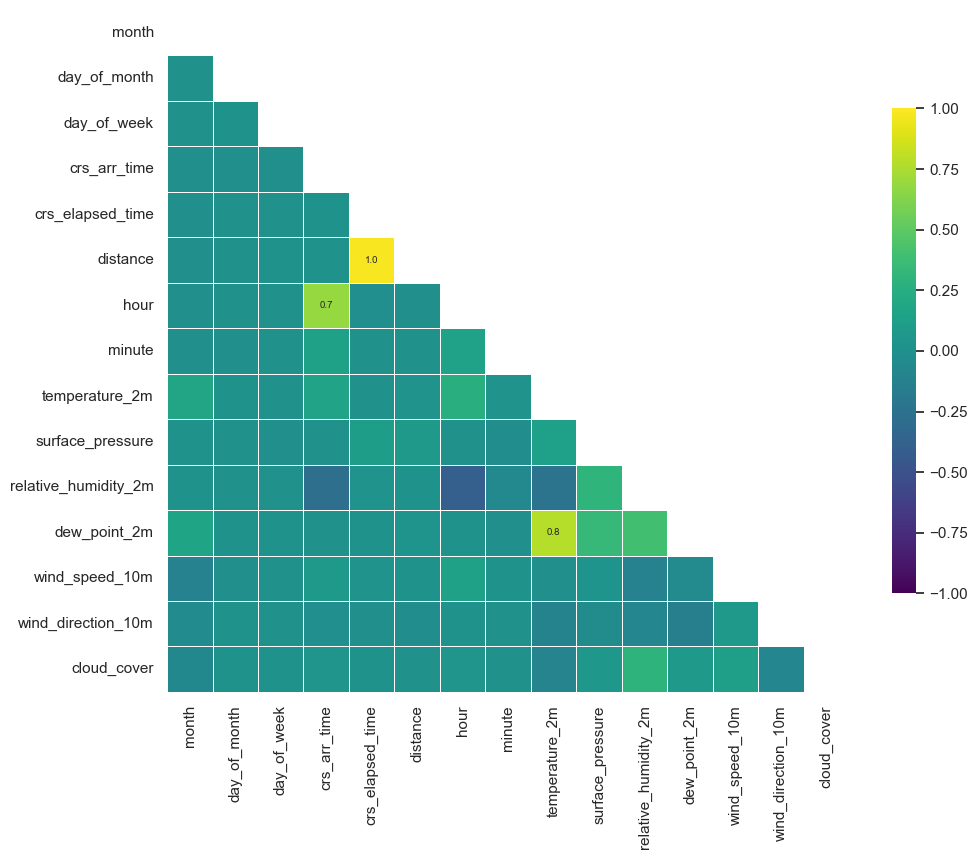

In [30]:
sns.set_theme(style='white')

Xs = train_ds.x.select_dtypes(include='number').astype('float64')
cols = Xs.columns
X_corr = np.corrcoef(Xs.to_numpy().T)# Xs.corr()
mask = np.triu(np.ones_like(X_corr, dtype=bool))
annot_matrix = np.where(np.abs(X_corr) >= 0.6, 
                        np.round(X_corr, 1).astype(str), 
                        "")

f, ax = plt.subplots(figsize=(11,9))
cmap = sns.color_palette('viridis', as_cmap=True)
sns.heatmap(X_corr,
            mask=mask,
            cmap=cmap,
            annot=annot_matrix,
            annot_kws={'fontsize':7},
            fmt="",
            xticklabels=cols,
            yticklabels=cols,
            vmax=1, vmin=-1,
            center=0,
            square=True,
            linewidths=.5,
            cbar_kws={"shrink": .7},
            
    );